## 1. Imports

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Data Loading & Vocabulary

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocab of all chars and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## 3. Dataset Building — Initial Exploration

In [5]:
#build the dataset
block_size = 3 # context length: how many chars do we take to predict the next one?
X, Y = [], [] # x input , y label
for w in words:#[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)
        

emma
olivia
ava
isabella
sophia
charlotte
mia
amelia
harper
evelyn
abigail
emily
elizabeth
mila
ella
avery
sofia
camila
aria
scarlett
victoria
madison
luna
grace
chloe
penelope
layla
riley
zoey
nora
lily
eleanor
hannah
lillian
addison
aubrey
ellie
stella
natalie
zoe
leah
hazel
violet
aurora
savannah
audrey
brooklyn
bella
claire
skylar
lucy
paisley
everly
anna
caroline
nova
genesis
emilia
kennedy
samantha
maya
willow
kinsley
naomi
aaliyah
elena
sarah
ariana
allison
gabriella
alice
madelyn
cora
ruby
eva
serenity
autumn
adeline
hailey
gianna
valentina
isla
eliana
quinn
nevaeh
ivy
sadie
piper
lydia
alexa
josephine
emery
julia
delilah
arianna
vivian
kaylee
sophie
brielle
madeline
peyton
rylee
clara
hadley
melanie
mackenzie
reagan
adalynn
liliana
aubree
jade
katherine
isabelle
natalia
raelynn
maria
athena
ximena
arya
leilani
taylor
faith
rose
kylie
alexandra
mary
margaret
lyla
ashley
amaya
eliza
brianna
bailey
andrea
khloe
jasmine
melody
iris
isabel
norah
annabelle
valeria
emerson
adalyn
ryl

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype
#X
#Y

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

## 4. Dataset Building — Refactored with Train / Dev / Test Splits

In [7]:
# Split up data : training split, dev/validation split, test split
# 80%, 10%, 10%

In [8]:
def build_dataset(words):
    block_size = 3 # context length: how many chars do we take to predict the next one?
    X, Y = [], [] # x input , y label
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words)) # 80% of words
n2 = int(0.9*len(words)) # 90% of words

Xtr, Ytr = build_dataset(words[:n1]) # n1
Xdev, Ydev = build_dataset(words[n1:n2]) # n2 - n1
Xte, Yte = build_dataset(words[n2:]) # len(words)-n2

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## 5. Embedding Layer — Exploration

In [9]:
C = torch.randn((27, 2))

In [10]:
# Identical output beacuse of matrix multiplication
#F.one_hot(torch.tensor(5), num_classes=27).float() @ C

In [11]:
# embedd a single char
C[5] # much faster then one_hot for now

tensor([1.3769, 0.0281])

In [12]:
#C[torch.tensor([5, 6, 7])]
#X[13,2]
#C[X].shape

In [13]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [14]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1) #.shape # 32,6 -> ugly not gneralized!

tensor([[ 1.1855,  0.8650,  1.1855,  0.8650,  1.1855,  0.8650],
        [ 1.1855,  0.8650,  1.1855,  0.8650,  1.3769,  0.0281],
        [ 1.1855,  0.8650,  1.3769,  0.0281, -0.3401, -1.4011],
        ...,
        [ 0.6938,  0.5148,  0.6938,  0.5148, -1.1621, -0.4621],
        [ 0.6938,  0.5148, -1.1621, -0.4621,  0.6938,  0.5148],
        [-1.1621, -0.4621,  0.6938,  0.5148,  1.0343, -0.2357]])

In [15]:
torch.cat(torch.unbind(emb, 1), 1) # same as above but generalized, not dependen on block size -> but inefficent and creates memory

tensor([[ 1.1855,  0.8650,  1.1855,  0.8650,  1.1855,  0.8650],
        [ 1.1855,  0.8650,  1.1855,  0.8650,  1.3769,  0.0281],
        [ 1.1855,  0.8650,  1.3769,  0.0281, -0.3401, -1.4011],
        ...,
        [ 0.6938,  0.5148,  0.6938,  0.5148, -1.1621, -0.4621],
        [ 0.6938,  0.5148, -1.1621, -0.4621,  0.6938,  0.5148],
        [-1.1621, -0.4621,  0.6938,  0.5148,  1.0343, -0.2357]])

In [16]:
a = torch.arange(18)
a
a.shape
a.view(3,3,2) # extremly efficient -> underlying storage, no mem changed, copied, created!
a.storage() # https://blog.ezyang.com/2019/05/pytorch-internals/ -> read this

/var/folders/yf/6vh8hl5571d6dcy1hwd5vnlr0000gn/T/ipykernel_99457/3103291533.py:5: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage() # https://blog.ezyang.com/2019/05/pytorch-internals/ -> read this


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

## 6. MLP Forward Pass — Exploration

In [17]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
#emb @ W1 + b1 this will not work

In [18]:
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)  # works because of view, can also use -1 

In [19]:
h

tensor([[ 0.7358,  0.8122,  1.0000,  ..., -0.9999,  0.5165,  0.9999],
        [-0.2280,  0.3416,  1.0000,  ..., -0.9990,  0.7717,  0.9999],
        [-0.8885, -0.4243,  0.9999,  ..., -0.5728,  0.1836,  0.9913],
        ...,
        [-0.0470, -0.6211,  0.9718,  ..., -0.8007, -0.3801,  0.2623],
        [ 0.9609,  0.9949,  0.9714,  ..., -0.8892, -0.9313,  0.8976],
        [ 0.4636, -0.9971,  0.8774,  ...,  0.7919,  0.9186, -0.5091]])

In [20]:
(emb.view(emb.shape[0], 6) @ W1).shape

torch.Size([228146, 100])

In [21]:
b1.shape

torch.Size([100])

In [22]:
# broadcasting rules!
# 32, 100
#  1, 100 -> 1 created fake val

In [23]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [24]:
logits = h @ W2 + b2

In [25]:
logits.shape

torch.Size([228146, 27])

In [26]:
counts = logits.exp()

In [27]:
prob = counts / counts.sum(1, keepdims=True)

In [28]:
prob.shape

torch.Size([228146, 27])

In [29]:
loss = -prob[torch.arange(32), Y].log().mean() # iterator from 0 to 31
loss

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [30]:
# issue with manual approach for educational purposes, cannot pass large logits
logits = torch.tensor([-5,-3, 0,5]) - 5
#logits = torch.tensor([-100,-3, 0,100])
counts = logits.exp()
probs = counts / counts.sum()
probs
#tensor([0., 0., 0., nan])

tensor([4.5079e-05, 3.3309e-04, 6.6903e-03, 9.9293e-01])

In [31]:
#counts
#tensor([3.7835e-44, 4.9787e-02, 1.0000e+00,        inf])

In [32]:
#logits.max(1)

## 7. Full Model — Proper Setup

In [33]:
### now more respectable

In [34]:
#X.shape, Y.shape # dataset
Xtr.shape, Ytr.shape # dataset training

(torch.Size([182625, 3]), torch.Size([182625]))

In [35]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g) # 1Odim embeds
W1 = torch.randn((30, 200), generator=g) # 300 neurons, 3x10 = 30
b1 = torch.randn(200, generator=g) # 300 biases
W2 = torch.randn((200, 27), generator=g) # 300 input
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [36]:
sum(p.nelement() for p in parameters) # num of params in total

11897

## 8. Training

In [37]:
for p in parameters:
    p.requires_grad = True

In [38]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [39]:
lri = []
lossi = []
stepi = []

In [40]:
for i in range(200000): #(1000):
    #minibatch construct
    #ix = torch.randint(0, X.shape[0], (32,))
    ix = torch.randint(0, Xtr.shape[0], (32,)) # training
    # forward pass
    #emb = C[X] # 32,3,2
    #emb = C[X[ix]] # 32,3,2
    emb = C[Xtr[ix]] # 32,3,2 -> training
    h = torch.tanh(emb.view(emb.shape[0], 30) @ W1 + b1) # 32,100
    logits = h @ W2 + b2 # 32, 27
    #counts = logits.exp()
    #prob = counts / counts.sum(1, keepdims=True)
    #loss = -prob[torch.arange(32), Y].log().mean()
    #loss = F.cross_entropy(logits, Y[ix]) # use pytroch api, forward and backward pass much more efficeitn
    loss = F.cross_entropy(logits, Ytr[ix]) # use pytroch api, forward and backward pass much more efficeitn -> training
    #print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    #lr = lrs[i]
    #lr = 0.01 #decay learning rate
    #lr = 0.01
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        #p.data += -0.1 * p.grad # we dont know if stepping is too fast or too slow how to determine?
        p.data += -lr * p.grad

    # track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())
    lossi.append(loss.log10().item())
    stepi.append(i)

#print(loss.item())

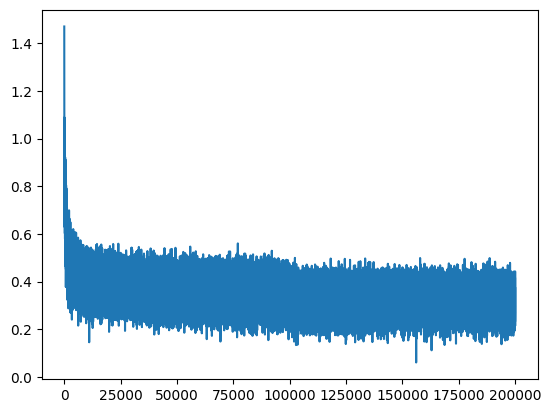

In [41]:
#plt.plot(lri, lossi) # plot learning rate (somewhere around 0.2?)
#plt.plot(lri, lossi) # between -1.0 and -0.5 -> 0.1 ? 
plt.plot(stepi, lossi)

In [42]:
print(loss.item())

2.356945276260376


## 9. Evaluation

In [43]:
# forward pass
#emb = C[X] # 32,3,2
emb = C[Xtr] # 32,3,2 # training split
h = torch.tanh(emb.view(emb.shape[0], 30) @ W1 + b1) # 32,100
logits = h @ W2 + b2 # 32, 27
#loss = F.cross_entropy(logits, Y) # use pytroch api, forward and backward pass much more efficeitn
loss = F.cross_entropy(logits, Ytr) # use pytroch api, forward and backward pass much more efficeitn
loss

tensor(2.1227, grad_fn=<NllLossBackward0>)

In [44]:
# forward pass
#emb = C[X] # 32,3,2
emb = C[Xdev] # 32,3,2 # dev split
h = torch.tanh(emb.view(emb.shape[0], 30) @ W1 + b1) # 32,100
logits = h @ W2 + b2 # 32, 27
#loss = F.cross_entropy(logits, Y) # use pytroch api, forward and backward pass much more efficeitn
loss = F.cross_entropy(logits, Ydev) # use pytroch api, forward and backward pass much more efficeitn
loss

tensor(2.1580, grad_fn=<NllLossBackward0>)

## 10. Embedding Visualization

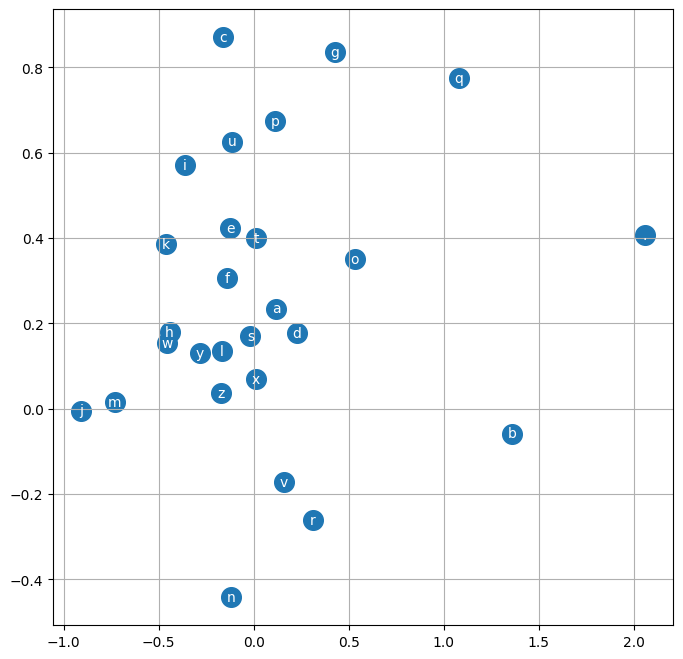

In [46]:
#embedding vectors visualize
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200) # x = C[:,0].data, y = C[:,1].data
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

### Sample from the model

In [47]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # init with all
    while True:
        emb = C[torch.tensor([context])] 
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carmahzato.
hari.
kemly.
reh.
cassanden.
jazhutna.
perric.
kaeli.
ner.
kentzeriav.
kaleigh.
ham.
jory.
quinn.
shonne.
liveni.
wazelo.
dearynix.
kael.
dusti.


## 11. Notes & References

In [ ]:
#https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf -> to read